## HateXplain - 2 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech - general
* **Target 2:** Hate speech against woman

In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes #, plot_pareto_plotly
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [7]:
task_config = {
    "hate_speech": {"type": "hate_speech"},
    "women": {"type": "group_hate", "group": "Women"},
    #"homosexual": {"type": "group_hate", "group": "Homosexual"},
    #"indigenous": {"type": "group_hate", "group": "Indigenous"},
    #"african": {"type": "group_hate", "group": "African"},
    #"asian": {"type": "group_hate", "group": "Asian"},
    #"jewish": {"type": "group_hate", "group": "Jewish"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [00:48<00:00,  9.89it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [8]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

13:02:30 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
13:02:30 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 104.51it/s]


Epoch 1 - Average loss: 0.3672


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 111.45it/s]


Epoch 2 - Average loss: 0.3587


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 111.95it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 112.49it/s]


Epoch 2 - Average loss: 0.2138


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 111.77it/s]


Epoch 3 - Average loss: 0.2146
new solution dominated [0.58921117 0.34999428]


13:23:44 | DEBUG | machinemoo | Calculated weights: [0.26145782 0.73854218]
13:23:44 | DEBUG | machinemoo | Importance: 0.00010212618030186471
13:23:44 | DEBUG | machinemoo | Global lower bound (y*): [0.58883907 0.34952017]
13:23:44 | DEBUG | machinemoo | Iteration 150
13:23:44 | DEBUG | machinemoo | Solutions list: [array([0.58883907, 0.35072498]), array([0.58934583, 0.34952017]), array([0.58896134, 0.34965628]), array([0.58887355, 0.3499954 ]), array([0.58895814, 0.34987635]), array([0.58886687, 0.35060525])]


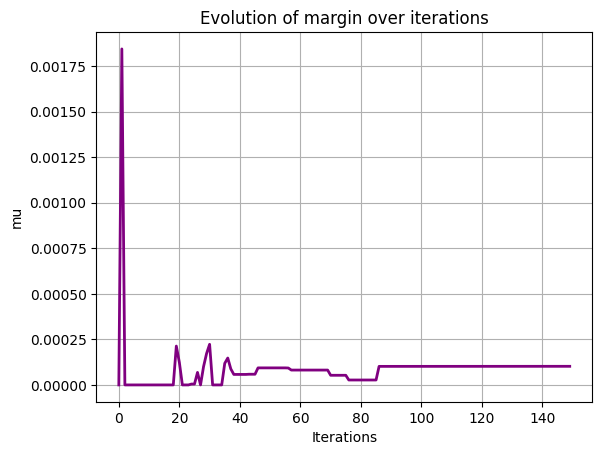

13:23:45 | INFO | machinemoo | Fit runtime: 1275.00 seconds


In [9]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

In [10]:
results['mola']["objectives"]

array([[0.58883907, 0.35072498],
       [0.58934583, 0.34952017],
       [0.58896134, 0.34965628],
       [0.58887355, 0.3499954 ],
       [0.58895814, 0.34987635],
       [0.58886687, 0.35060525]])

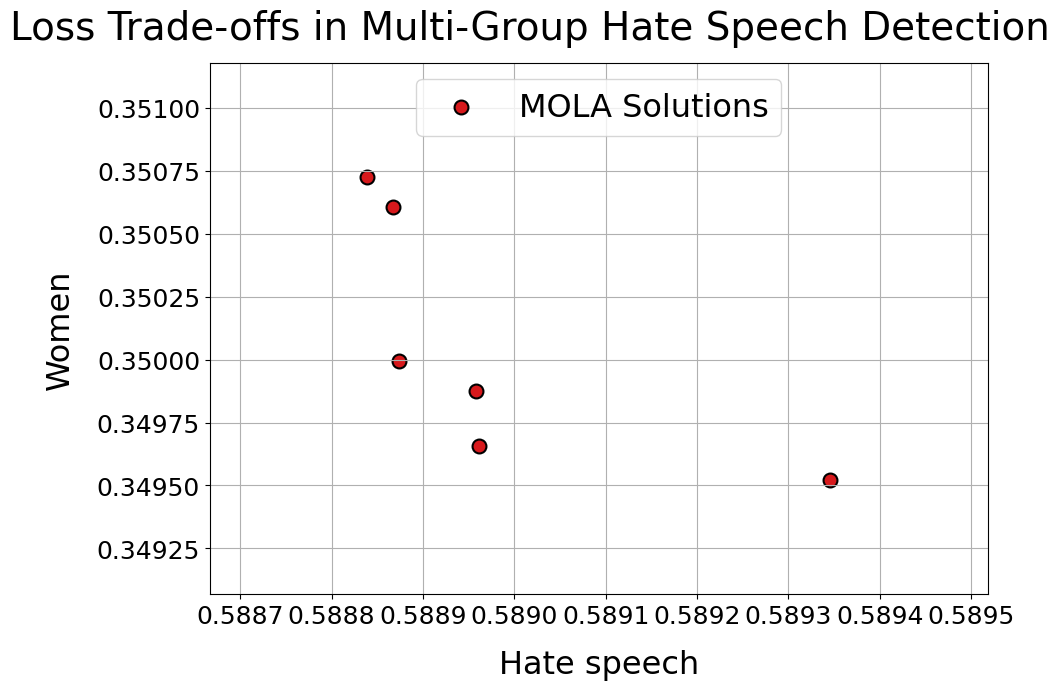

In [11]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_2.pdf'
            )

13:23:45 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
13:23:45 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 112.00it/s]


Epoch 1 - Average loss: 0.3593


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 114.07it/s]


Epoch 2 - Average loss: 0.3525


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 114.15it/s]


...

Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 112.59it/s]


Epoch 3 - Average loss: 0.3068


13:44:23 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [0.37915784 0.25796445]


new solution dominated [0.58895299 0.36583252]


13:44:23 | DEBUG | machinemoo | Calculated weights: [1. 0.]
13:44:23 | DEBUG | machinemoo | Importance: 0.20949176658733282
13:44:23 | DEBUG | machinemoo | Global lower bound (y*): [0.37915784 0.25796445]
13:44:23 | DEBUG | machinemoo | Iteration 150
13:44:23 | DEBUG | machinemoo | Solutions list: [array([0.58864961, 0.36418853]), array([0.58873251, 0.36333269]), array([0.58889807, 0.36323186]), array([0.58890099, 0.36286169]), array([0.58937959, 0.36277534]), array([0.58932962, 0.36283065]), array([0.59146824, 0.36252915]), array([0.59209379, 0.36235276])]


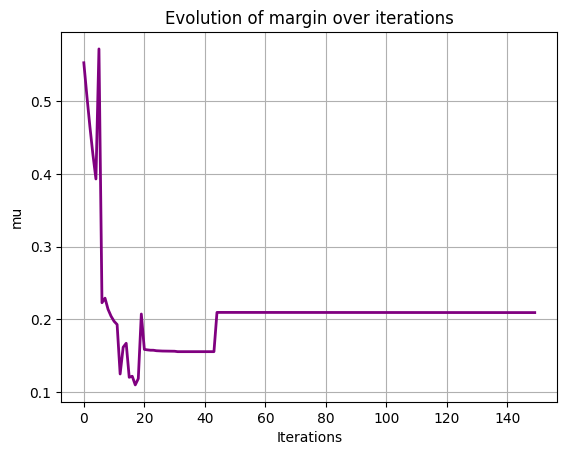

13:44:23 | INFO | machinemoo | Fit runtime: 1237.95 seconds


In [ ]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True
                            )
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

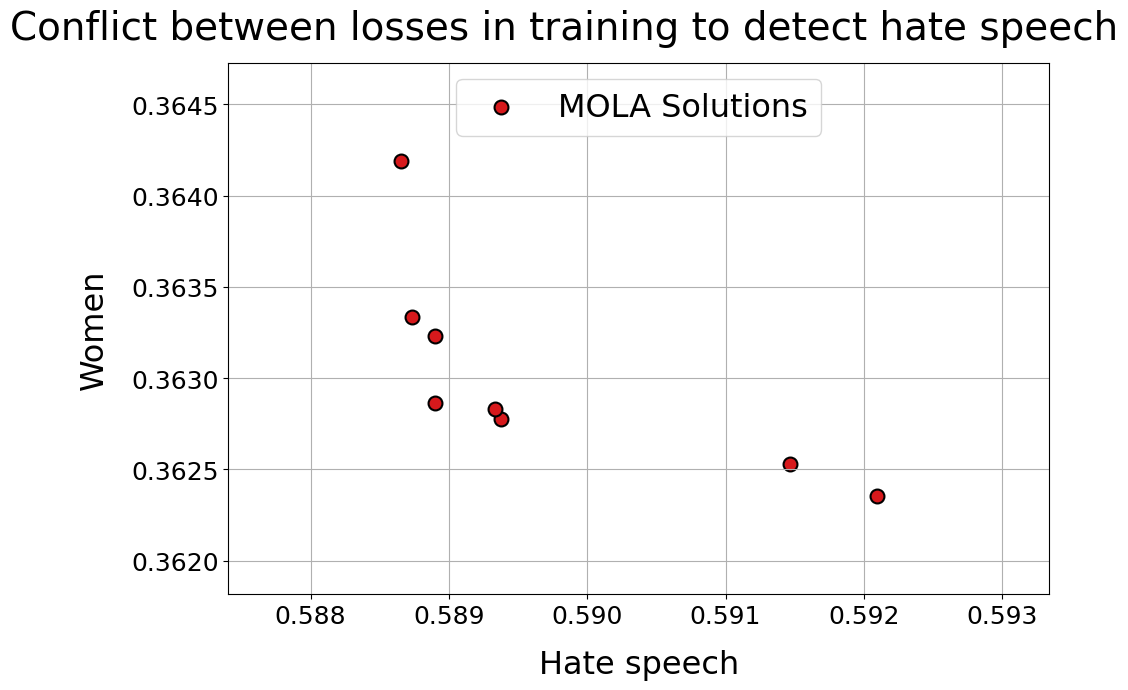

In [18]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'mola': results["mola_grad"]["objectives"]},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_mola_grad_2.pdf'
            )

### Random Weight

In [ ]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

13:44:23 | WARNING | machinemoo | Ignored parameters for random_weights: {'targetGap', 'nodeGap', 'nodeTimeLimit'}
13:44:23 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
13:44:23 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 111.45it/s]


Epoch 1 - Average loss: 0.3680


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 112.90it/s]


Epoch 2 - Average loss: 0.3593


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 110.43it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:04<00:00, 56.91it/s]


Epoch 2 - Average loss: 0.2437


Epoch 3/3: 100%|██████████| 241/241 [00:03<00:00, 64.80it/s]


Epoch 3 - Average loss: 0.2443


14:21:34 | DEBUG | machinemoo | 150th solution


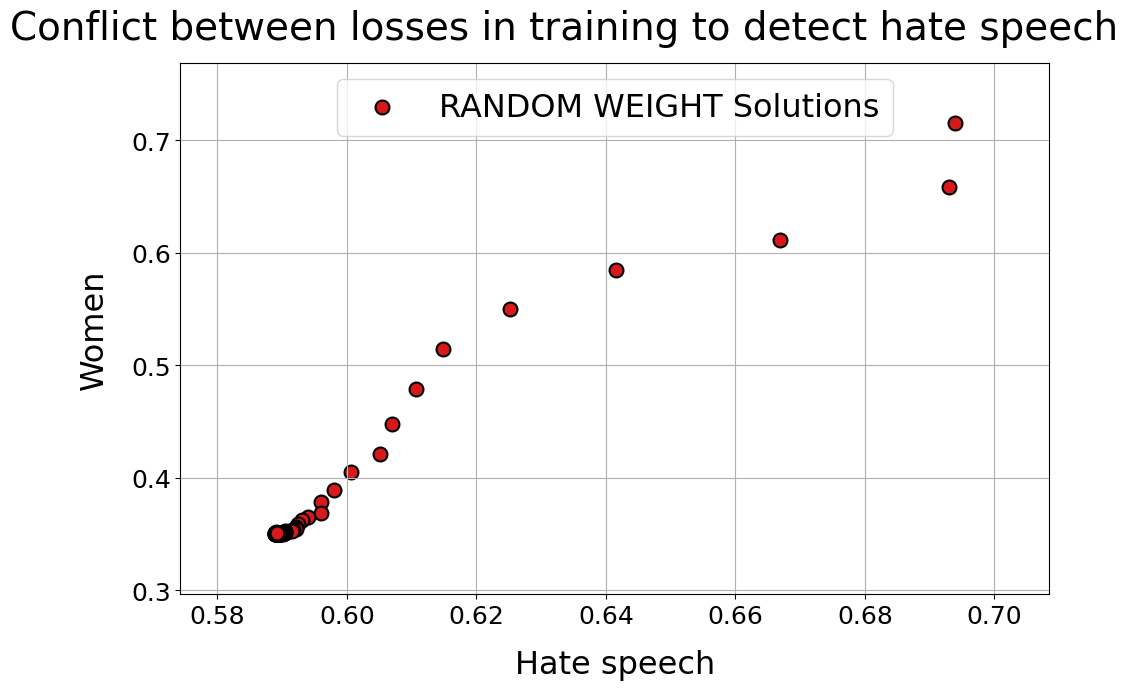

In [ ]:
title="Conflict between losses in training to detect hate speech"
plot_pareto(methods={'random_weight': results["random_weight"]["objectives"]},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_rw_2.pdf'
            )

## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

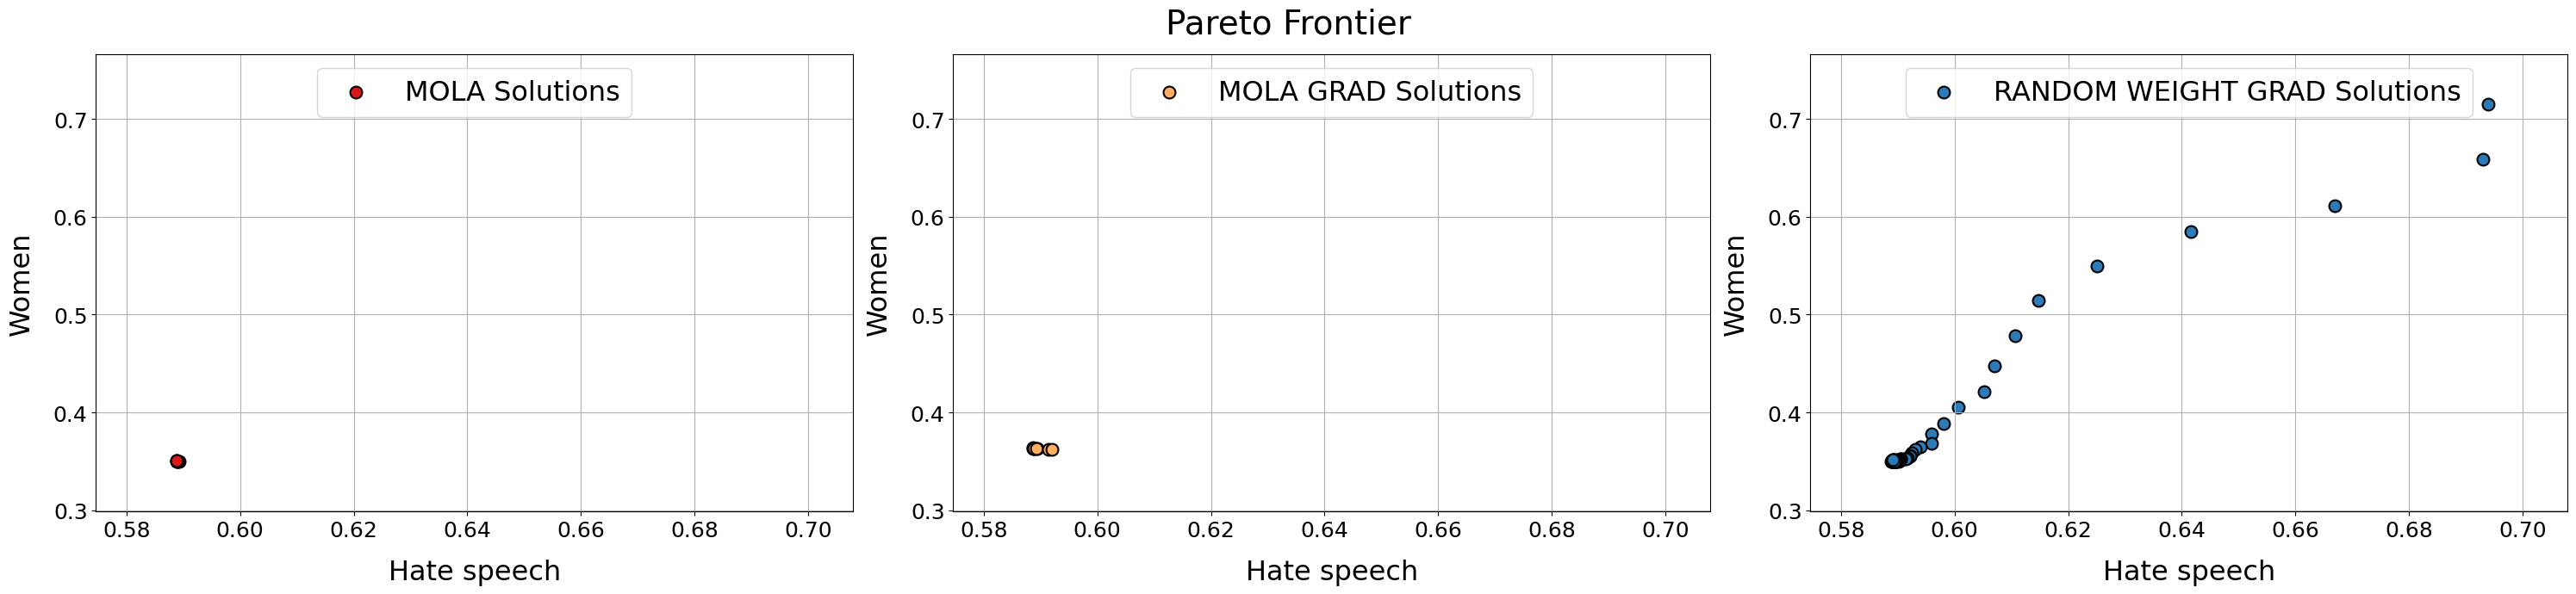

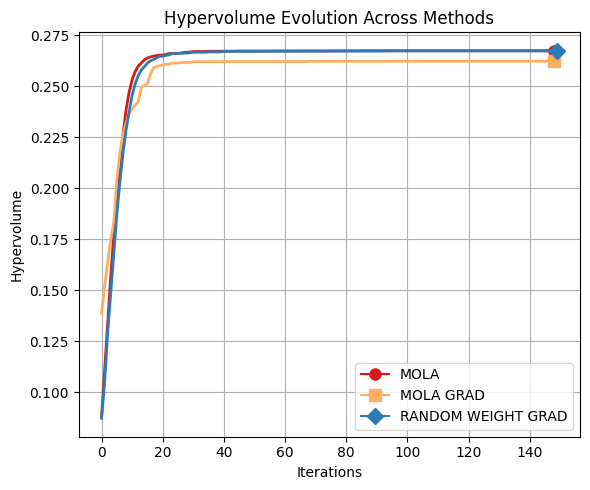

In [15]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

colors_pareto = ['#FF5C8D', '#FF5C8D', '#FF5C8D']
colors_hv = ['#FF5C8D', '#4BD6A0', '#9D5CFF']
title = ""
plot_pareto(methods=pareto_dict,
            labels=task_names, 
            # title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/2_objs_methods_2.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)

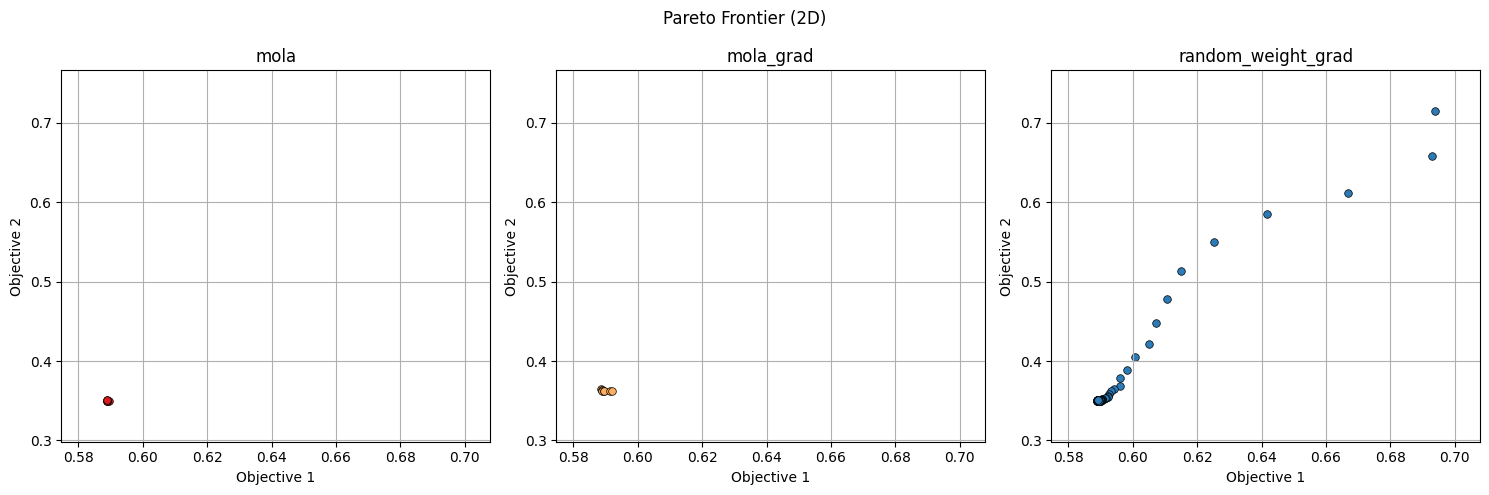

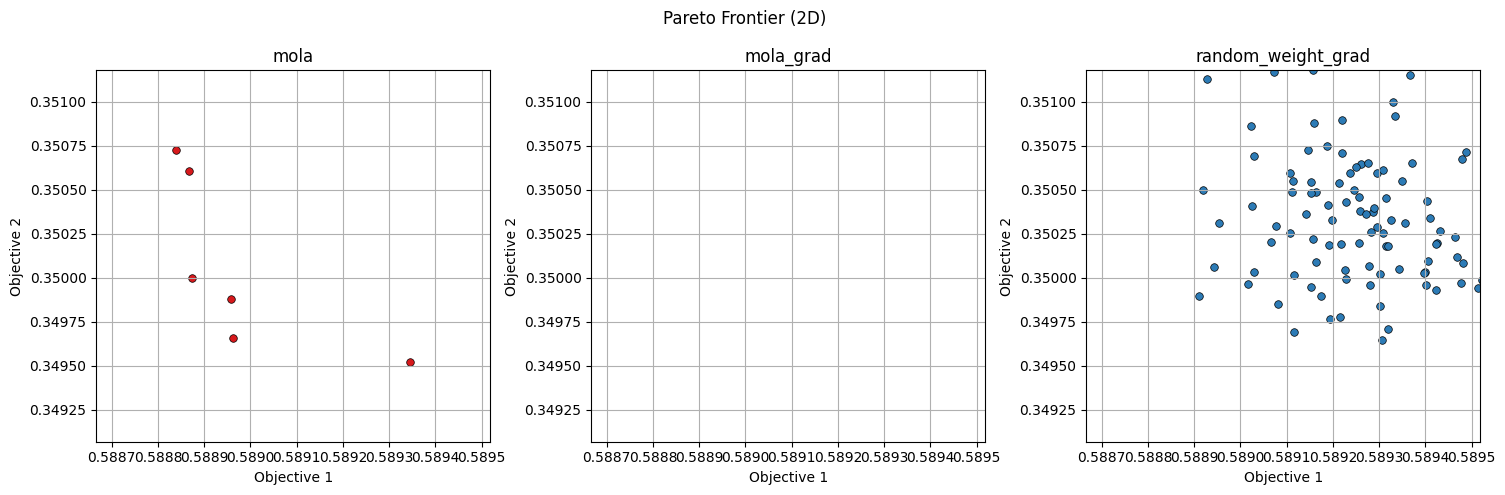

In [16]:
from machinemoo.analysis.visualization import plot_pareto_2d_set_limit
plot_pareto_2d_set_limit(pareto_dict=pareto_dict, axis_mode="global")
plot_pareto_2d_set_limit(pareto_dict=pareto_dict, axis_mode="first")